## Load and Validate

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

BASE = Path().resolve().parent
OUTPUTS = BASE / "outputs"
DATA = BASE / 'data'

plt.rcParams.update({
    'figure.facecolor': '#0C0A14', 'axes.facecolor': '#13102A',
    'axes.edgecolor': '#2D2040', 'text.color': '#E2D9F3',
    'axes.labelcolor': '#9B8CB8', 'xtick.color': '#9B8CB8',
    'ytick.color': '#9B8CB8', 'grid.color': '#2D2040', 'grid.alpha': 0.5,
})

In [54]:
df= pd.read_csv(f"{DATA}/funnel_events.csv",
                parse_dates=['ad_date', 'signup_date', 'trial_date', 'paid_date'])
print(f"shape: {df.shape}")
print(f'Nulls: {df.isnull().sum()}')
print(f'Channel Distribution: {df["channel"].value_counts()}')

shape: (10000, 14)
Nulls: user_id            0
channel            0
device             0
course_interest    0
ad_date            0
reached_landing    0
signed_up          0
started_trial      0
converted_paid     0
signup_date        0
trial_date         0
paid_date          0
revenue            0
cpc                0
dtype: int64
Channel Distribution: channel
Google Ads      3505
Facebook Ads    2557
Organic SEO     1712
YouTube Ads     1449
Referral         777
Name: count, dtype: int64


In [55]:
df.head(5)

,user_id,channel,device,course_interest,ad_date,reached_landing,signed_up,started_trial,converted_paid,signup_date,trial_date,paid_date,revenue,cpc
0,USR-001,YouTube Ads,Desktop,Design,2025-10-26 10:13:00,False,False,False,False,2025-10-26 10:42:00,2025-10-26 21:42:00,2025-10-29 21:42:00,0,45
1,USR-002,Organic SEO,Mobile,Web Dev,2025-05-26 19:59:00,False,False,False,False,2025-05-26 21:00:00,2025-05-28 03:00:00,2025-06-18 03:00:00,0,0
2,USR-003,Referral,Mobile,Web Dev,2025-08-16 18:19:00,True,False,False,False,2025-08-16 19:51:00,2025-08-17 12:51:00,2025-09-06 12:51:00,0,20
3,USR-004,Google Ads,Mobile,Digital Marketing,2025-10-05 18:23:00,False,False,False,False,2025-10-05 18:32:00,2025-10-06 08:32:00,2025-10-17 08:32:00,0,120
4,USR-005,Google Ads,Mobile,Digital Marketing,2025-05-06 18:38:00,False,False,False,False,2025-05-06 20:27:00,2025-05-08 04:27:00,2025-05-18 04:27:00,0,120


## Feature Engineering

In [56]:
# month for cohort analysis
df['month'] = df['ad_date'].dt.month
df['month_name'] = df['ad_date'].dt.month_name()
df['month_num'] = df['ad_date'].dt.month
df['week'] = df['ad_date'].dt.isocalendar().week.astype(int)
df['day_of_week'] = df['ad_date'].dt.day_name()

# Time-to-convert at each stage(hours)
df['hours_to_signup'] = (
    (df['signup_date'] - df['ad_date']).dt.total_seconds() / 3600
).where(df['signed_up'])

df['hours_to_trial'] = (
    (df['trial_date'] - df['ad_date']).dt.total_seconds() / 3600
).where(df['started_trial'])

df['days_to_paid'] = (
    (df['paid_date'] - df['trial_date']).dt.total_seconds() / 3600 / 24
).where(df['converted_paid'])

# Funnel stage reached (categorical - useful for groupby)
def funnel_stage(row):
    if row['converted_paid']: return 'Paid'
    if row['started_trial']: return 'Trial'
    if row['signed_up']: return 'Signup'
    if row['reached_landing']: return 'Landing'
    return 'Ad Only'

df['furthest_stage'] = df.apply(funnel_stage, axis=1)

# Cost per user acquired (CPC = cost per click/landing visit)
df['acquisition_cost'] = df['cpc']

print("Feature Engineering complete")
print(df[['user_id', 'channel', 'furthest_stage',
      'hours_to_signup', 'hours_to_trial', 'days_to_paid']])

df.to_csv(f'{DATA}/funnel_enriched.csv', index=False)

Feature Engineering complete
        user_id       channel furthest_stage  hours_to_signup  hours_to_trial  \
0       USR-001   YouTube Ads        Ad Only              NaN             NaN   
1       USR-002   Organic SEO        Ad Only              NaN             NaN   
2       USR-003      Referral        Landing              NaN             NaN   
3       USR-004    Google Ads        Ad Only              NaN             NaN   
4       USR-005    Google Ads        Ad Only              NaN             NaN   
...         ...           ...            ...              ...             ...   
9995   USR-9996    Google Ads        Landing              NaN             NaN   
9996   USR-9997    Google Ads        Ad Only              NaN             NaN   
9997   USR-9998  Facebook Ads        Ad Only              NaN             NaN   
9998   USR-9999  Facebook Ads        Ad Only              NaN             NaN   
9999  USR-10000    Google Ads        Landing              NaN             NaN   

## Validation

In [57]:
print("=== FUNNEL STAGE VOLUMES ===")
stages = ['reached_landing', 'signed_up', 'started_trial', 'converted_paid']
stage_labels = ['Landing Page', 'Signup', 'Trail', 'Paid']
for col, label in zip(stages, stage_labels):
    n = df[col].sum()
    pct_of_impressions = n / len(df) * 100
    print(f'{label:15} {n:5,} ({pct_of_impressions:.2f}% of impressions)')

print("\n=== STAGE-TO-STAGE CONVERSION RATES ===")
n_imp = len(df)
n_land = df['reached_landing'].sum()
n_sign = df['signed_up'].sum()
n_trial = df['started_trial'].sum()
n_paid = df['converted_paid'].sum()

print(f"Impression -> Landing: {n_land/n_imp*100:.1f}%")
print(f"Landing -> Signup: {n_sign/n_land*100:.1f}%")
print(f"Signup -> Trial: {n_trial/n_sign*100:.1f}%")
print(f"Trial -> Paid: {n_paid/n_trial*100:.1f}%")
print(f"Overall (Imp -> Paid): {n_paid/n_imp*100:.1f}%")

print("\n=== REVENUE SUMMARY ===")
print(f'Total revenue: ₹{df['revenue'].sum():,.0f}')
print(f"Paying users: {n_paid}")
print(f"Avg order value: ₹{df[df['converted_paid']]['revenue'].mean():,.0f}")

=== FUNNEL STAGE VOLUMES ===
Landing Page    6,486 (64.86% of impressions)
Signup          2,327 (23.27% of impressions)
Trail           1,357 (13.57% of impressions)
Paid              251 (2.51% of impressions)

=== STAGE-TO-STAGE CONVERSION RATES ===
Impression -> Landing: 64.9%
Landing -> Signup: 35.9%
Signup -> Trial: 58.3%
Trial -> Paid: 18.5%
Overall (Imp -> Paid): 2.5%

=== REVENUE SUMMARY ===
Total revenue: ₹1,464,749
Paying users: 251
Avg order value: ₹5,836


# Funnel Analysis
---
### Overall Funnel chart - the waterfall

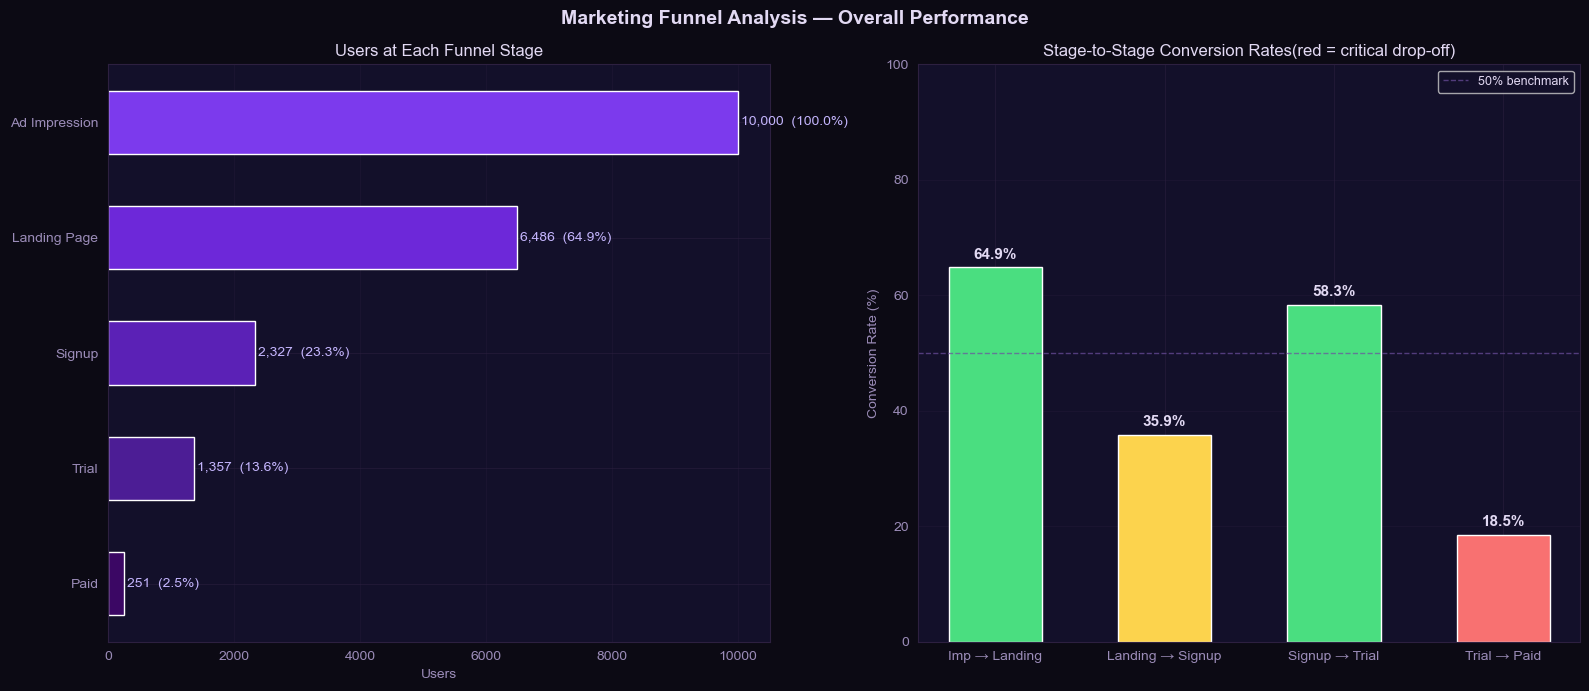

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Marketing Funnel Analysis — Overall Performance",
             fontsize=14, fontweight="bold", color="#E2D9F3")

stages      = ["Ad Impression","Landing Page","Signup","Trial","Paid"]
stage_cols  = [len(df), n_land, n_sign, n_trial, n_paid]
colors      = ["#7C3AED","#6D28D9","#5B21B6","#4C1D95","#3B0764"]

# --- Funnel bar chart ---
bars = axes[0].barh(stages[::-1], stage_cols[::-1], color=colors[::-1],
                    height=0.55)
axes[0].set_xlabel("Users")
axes[0].set_title("Users at Each Funnel Stage", color="#E2D9F3", fontsize=12)
axes[0].grid(True, alpha=0.3, axis="x")

# Annotate with counts and % of total
for bar, count, stage in zip(bars, stage_cols[::-1], stages[::-1]):
    pct = count / len(df) * 100
    axes[0].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                 f"{count:,}  ({pct:.1f}%)",
                 va="center", fontsize=10, color="#C4B5FD")

# --- Stage-to-stage conversion rate chart ---
conversions = [
    ("Imp → Landing",  n_land/len(df)*100),
    ("Landing → Signup", n_sign/n_land*100),
    ("Signup → Trial",   n_trial/n_sign*100),
    ("Trial → Paid",     n_paid/n_trial*100),
]
labels = [c[0] for c in conversions]
values = [c[1] for c in conversions]
bar_colors = ["#F87171" if v < 20 else "#FCD34D" if v < 40 else "#4ADE80"
              for v in values]

bars2 = axes[1].bar(labels, values, color=bar_colors, width=0.55)
axes[1].axhline(50, color="#6D4FA0", linestyle="--", linewidth=1,
                label="50% benchmark", alpha=0.7)
axes[1].set_ylabel("Conversion Rate (%)")
axes[1].set_title("Stage-to-Stage Conversion Rates(red = critical drop-off)",
                  color="#E2D9F3", fontsize=12)
axes[1].set_ylim(0, 100)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis="y")

for bar, val in zip(bars2, values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1.5,
                 f"{val:.1f}%", ha="center", fontsize=11,
                 fontweight="bold", color="#E2D9F3")

plt.tight_layout()
plt.savefig(f"{OUTPUTS}/charts/01_overall_funnel.png",
            dpi=150, bbox_inches="tight", facecolor="#0C0A14")
plt.show()

### Drop-off analysis - how much revenue is lost at each stage

=== REVENUE OPPORTUNITY ANALYSIS ===
Users who dropped at Trial stage: 6,235
If 10% recovered: +624 users x ₹5,836 = ₹3,638,530 additional revenue
----------------------------------------
Users who dropped at Signup stage: 970
if 5% recovered: +485 users x ₹523,510 additional revenue


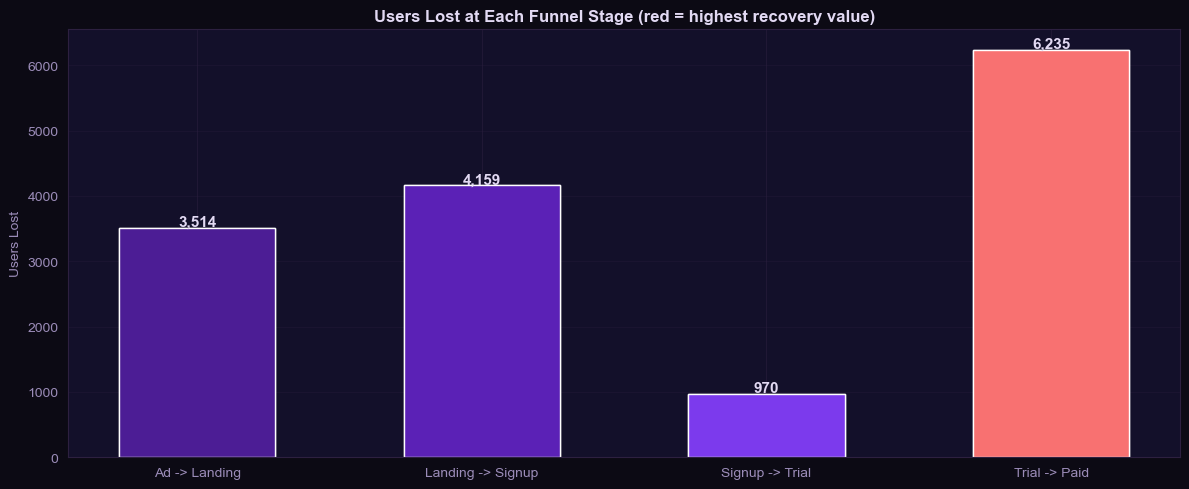

In [59]:
# calculate potential revenue lost at each drop-off point
avg_rev = df[df['converted_paid']]['revenue'].mean()

# user who dropped at each stage (never reached next stage)
dropped_at_landing = len(df) - n_land
dropped_at_signup = n_land - n_sign
dropped_at_trial = n_sign - n_trial
dropped_at_paid = n_land - n_paid

# trial to paid rate from actual data
t2p_rate = n_paid / n_trial

potential_from_signup_drops = dropped_at_trial * t2p_rate * avg_rev
potential_from_trial_drops = dropped_at_paid * avg_rev

print("=== REVENUE OPPORTUNITY ANALYSIS ===")
print(f"Users who dropped at Trial stage: {dropped_at_paid:,}")
print(
    f"If 10% recovered: +{dropped_at_paid*0.10:,.0f} users x ₹{avg_rev:,.0f} = "
     f"₹{dropped_at_paid*0.10*avg_rev:,.0f} additional revenue" )
print("--"*20)
print(f"Users who dropped at Signup stage: {dropped_at_trial:,}")
print(
    f"if 5% recovered: +{dropped_at_trial*0.5:,.0f} users x "
    f"₹{dropped_at_trial*0.5*avg_rev*t2p_rate:,.0f} additional revenue"
)

# Chart - lost users per stage
fig, ax = plt.subplots(figsize=(12, 5))
drop_stages = ['Ad -> Landing', "Landing -> Signup", "Signup -> Trial", "Trial -> Paid"]
drop_counts = [dropped_at_landing, dropped_at_signup,
               dropped_at_trial, dropped_at_paid]
bar_cols = ["#4C1D95","#5B21B6","#7C3AED","#F87171"]

bars = ax.bar(drop_stages, drop_counts, width=0.55, color=bar_cols)
bars = ax.bar(drop_stages, drop_counts, color=bar_cols, width=0.55)
ax.set_ylabel("Users Lost")
ax.set_title("Users Lost at Each Funnel Stage (red = highest recovery value)",
             fontsize=12, fontweight="bold", color="#E2D9F3")
for bar, count in zip(bars, drop_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{count:,}", ha="center", fontsize=11,
            fontweight="bold", color="#E2D9F3")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(f"{OUTPUTS}/charts/02_dropoff_analysis.png",
            dpi=150, bbox_inches="tight", facecolor="#0C0A14")
plt.show()

### Funnel by device type

In [60]:
device_funnel = df.groupby('device').agg(
    impressions = ('user_id', 'count'),
    landing = ('reached_landing', 'sum'),
    signups = ('signed_up', 'sum'),
    trials = ('started_trial', 'sum'),
    paid = ('converted_paid', 'sum'),
    revenue = ('revenue', 'sum'),
).reset_index()

device_funnel['overall_cvr'] = (
    device_funnel['paid'] / device_funnel['impressions'] * 100
).round(2)

device_funnel['trial_to_paid'] = (
    device_funnel['paid'] / device_funnel['trials'] * 100
).round(1)

print("=== CONVERSION BY DEVICE ===")
print(device_funnel[['device', 'impressions', 'paid',
                     'overall_cvr', 'trial_to_paid', 'revenue']].to_string(index=False))

=== CONVERSION BY DEVICE ===
 device  impressions  paid  overall_cvr  trial_to_paid  revenue
Desktop         3681    96         2.61           18.6   528904
 Mobile         5617   141         2.51           18.8   852859
 Tablet          702    14         1.99           15.6    82986


# Channel ROI
---
### Channel Performance Table

In [61]:
channel_stats = df.groupby('channel').agg(
    impressions = ('user_id', 'count'),
    landing = ('reached_landing', 'sum'),
    signups = ('signed_up', 'sum'),
    trials = ('started_trial', 'sum'),
    paid_users = ('converted_paid', 'sum'),
    total_revenue = ('revenue', 'sum'),
    total_cost = ('acquisition_cost', 'sum'),
).reset_index()

# conversion rates
channel_stats['land_cvr'] = (channel_stats['landing'] /
                             channel_stats['impressions'] * 100).round(1)
channel_stats['signup_cvr'] = (channel_stats['signups'] /
                               channel_stats['landing'] * 100).round(1)
channel_stats['trial_cvr'] = (channel_stats['trials'] /
                              channel_stats['signups'] * 100).round(1)
channel_stats['paid_cvr'] = (channel_stats['paid_users'] /
                             channel_stats['trials'] * 100).round(1)
channel_stats['overall_cvr'] = (channel_stats['paid_users'] /
                                channel_stats['impressions'] * 100).round(1)

# ROI metrics
channel_stats['cac'] = (
    channel_stats['total_cost'] / channel_stats['paid_users']
).round(0)

channel_stats['avg_revenue_per_paid'] = (
    channel_stats['total_revenue'] / channel_stats['paid_users']
).round(0)

channel_stats['roi_pct'] = (
    (channel_stats['total_revenue'] - channel_stats['total_cost'])
    / channel_stats['total_cost'] * 100
).round(1)

channel_stats['ltv_cac_ratio'] = (
    channel_stats['avg_revenue_per_paid'] / channel_stats['cac']
).round(2)

print("=== CHANNEL PERFORMANCE SUMMARY ===")
cols = ['channel', 'impressions', 'paid_users', 'overall_cvr',
        'cac', 'avg_revenue_per_paid', 'roi_pct', 'ltv_cac_ratio']
print(channel_stats[cols].sort_values('roi_pct', ascending=False).to_string(index=False))

=== CHANNEL PERFORMANCE SUMMARY ===
     channel  impressions  paid_users  overall_cvr    cac  avg_revenue_per_paid  roi_pct  ltv_cac_ratio
 Organic SEO         1712          56          3.3    0.0                5856.0      inf            inf
    Referral          777          52          6.7  299.0                6384.0   2036.1          21.35
 YouTube Ads         1449          30          2.1 2174.0                5632.0    159.1           2.59
Facebook Ads         2557          35          1.4 4749.0                6142.0     29.3           1.29
  Google Ads         3505          78          2.2 5392.0                5396.0      0.1           1.00


### Channel Comparison Charts

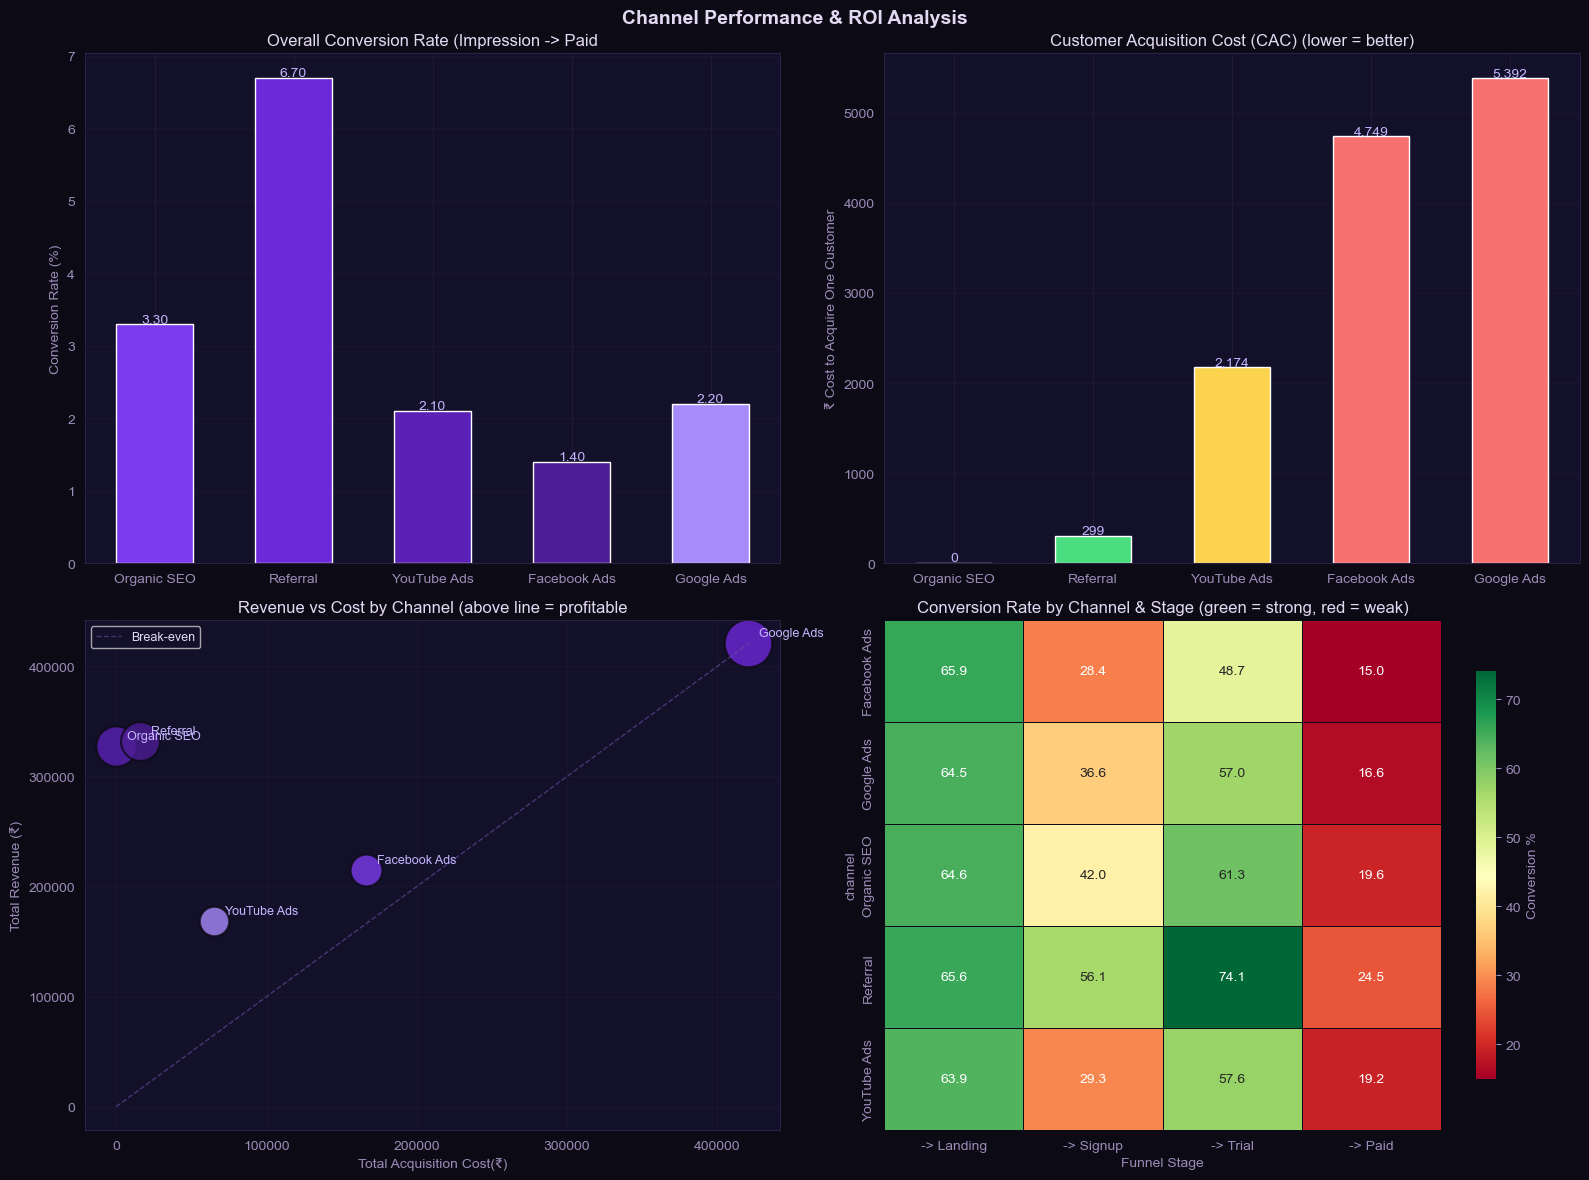

In [62]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Channel Performance & ROI Analysis",
             fontsize=14, fontweight='bold', color="#E2D9F3")

ch_order = channel_stats.sort_values('roi_pct', ascending=False)['channel'].tolist()
ch_colors = ["#7C3AED","#6D28D9","#5B21B6","#4C1D95","#A78BFA"]

# Chart 1 - overall conversion rate by channel
cvr = channel_stats.set_index('channel').reindex(ch_order)['overall_cvr']
bars = axes[0, 0].bar(ch_order, cvr.values, color=ch_colors, width=0.55)
axes[0,0].set_ylabel("Conversion Rate (%)")
axes[0,0].set_title("Overall Conversion Rate (Impression -> Paid", color="#E2D9F3")
for bar, val in zip(bars, cvr.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                   f"{val:,.2f}", ha="center", color="#C4B5FD", fontsize=10)
axes[0,0].grid(True, alpha=0.3, axis="y")

# Chart 2 - CAC by Channel
cac_vals = channel_stats.set_index('channel').reindex(ch_order)['cac']
bar_colors2 = ["#4ADE80" if v < 1000 else "#FCD34D" if v < 3000 else "#F87171"
               for v in cac_vals.values]
bars2 = axes[0, 1].bar(ch_order, cac_vals.values, color=bar_colors2, width=0.55)
axes[0,1].set_ylabel("₹ Cost to Acquire One Customer")
axes[0,1].set_title("Customer Acquisition Cost (CAC) (lower = better)", color="#E2D9F3")
for bar, val in zip(bars2, cac_vals.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                   f"{val:,.0f}", ha="center", color="#C4B5FD", fontsize=10)
axes[0,1].grid(True, alpha=0.3, axis="y")

# Chart 3 - Revenue vs Cost scatter (bubble = paid users)
for i, (_, row) in enumerate(channel_stats.iterrows()):
    axes[1,0].scatter(row['total_cost'], row['total_revenue'],
                      s=row['paid_users']*15, color=ch_colors[i],
                      alpha=0.8, edgecolors="#0C0A14", linewidths=1.5)
    axes[1,0].annotate(row['channel'],
                       (row['total_cost'], row['total_revenue']),
                       fontsize=9, color='#C4B5FD',
                       xytext=(8, 5), textcoords="offset points")
# Break even line
max_val = max(channel_stats['total_revenue'].max(),
              channel_stats['total_cost'].max())
axes[1,0].plot([0, max_val], [0, max_val], "--", color="#6D4FA0",
               linewidth=1, alpha=0.6, label="Break-even")
axes[1,0].set_xlabel("Total Acquisition Cost(₹)")
axes[1,0].set_ylabel("Total Revenue (₹)")
axes[1,0].set_title("Revenue vs Cost by Channel (above line = profitable", color="#E2D9F3")
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(True, alpha=0.3)

# Chart 4 - Funnel heatmap by channel
funnel_metrics = channel_stats.set_index('channel')[
    ['land_cvr', 'signup_cvr', 'trial_cvr', 'paid_cvr']
].rename(columns={
    'land_cvr': '-> Landing',
    'signup_cvr': '-> Signup',
    'trial_cvr': '-> Trial',
    'paid_cvr': '-> Paid',
})
sns.heatmap(funnel_metrics, ax=axes[1,1], cmap='RdYlGn',
            annot=True, fmt=".1f",
            cbar_kws={"label": "Conversion %", 'shrink':0.8},
            linewidths=.5, linecolor='#0C0A14')
axes[1,1].set_title("Conversion Rate by Channel & Stage (green = strong, red = weak)", color="#E2D9F3" )
axes[1,1].set_xlabel("Funnel Stage")
plt.tight_layout()
plt.savefig(f"{OUTPUTS}/charts/03_channel_analysis.png",
            dpi=150, bbox_inches="tight", facecolor="#0C0A14")
plt.show()


### ROI Ranking - the budget recommendation

In [63]:
print("=== CHANNEL ROI RANKING — BUDGET RECOMMENDATION ===")

ranking = channel_stats.sort_values("roi_pct", ascending=False)

for rank, (_, row) in enumerate(ranking.iterrows(), 1):
    roi_str = f"{row['roi_pct']:.0f}%" if row['roi_pct'] < 10000 else "N/A (zero cost)"
    print(f"#{rank} {row['channel']}")
    print(f"   Paid users:    {row['paid_users']:.0f}")
    print(f"   CAC:           ₹{row['cac']:,.0f}")
    print(f"   Avg revenue:   ₹{row['avg_revenue_per_paid']:,.0f}")
    print(f"   LTV:CAC ratio: {row['ltv_cac_ratio']:.1f}x")
    print(f"   ROI:           {roi_str}")
    print()

=== CHANNEL ROI RANKING — BUDGET RECOMMENDATION ===
#1 Organic SEO
   Paid users:    56
   CAC:           ₹0
   Avg revenue:   ₹5,856
   LTV:CAC ratio: infx
   ROI:           N/A (zero cost)

#2 Referral
   Paid users:    52
   CAC:           ₹299
   Avg revenue:   ₹6,384
   LTV:CAC ratio: 21.4x
   ROI:           2036%

#3 YouTube Ads
   Paid users:    30
   CAC:           ₹2,174
   Avg revenue:   ₹5,632
   LTV:CAC ratio: 2.6x
   ROI:           159%

#4 Facebook Ads
   Paid users:    35
   CAC:           ₹4,749
   Avg revenue:   ₹6,142
   LTV:CAC ratio: 1.3x
   ROI:           29%

#5 Google Ads
   Paid users:    78
   CAC:           ₹5,392
   Avg revenue:   ₹5,396
   LTV:CAC ratio: 1.0x
   ROI:           0%



# Cohort Analysis
---
### Monthly cohort conversion rates

In [64]:
# only looking at users who at least signed up
signed = df[df['signed_up']].copy()
signed['cohort_month'] = signed['signup_date'].dt.month_name()
signed['cohort_num'] = signed['signup_date'].dt.month

cohort_stats = signed.groupby(['cohort_num', 'cohort_month']).agg(
    signups = ('user_id', 'count'),
    trials = ('started_trial','sum'),
    paid = ('converted_paid', 'sum'),
    revenue = ('revenue', 'sum'),
).reset_index().sort_values('cohort_num')

cohort_stats['trial_rate'] = (
    cohort_stats['trials'] / cohort_stats['signups'] * 100
).round(1)
cohort_stats['paid_rate'] = (
    cohort_stats['paid'] / cohort_stats['signups'] * 100
).round(1)
cohort_stats['trial_to_paid'] = (
    cohort_stats['paid'] / cohort_stats['trials'] * 100
).round(1)

print("=== MONTHLY COHORT PERFORMANCE ===")
print(cohort_stats[['cohort_month', 'signups', 'trials', 'paid',
                    'trial_rate', 'paid_rate', 'trial_to_paid',
                    'revenue']].to_string(index=False))

=== MONTHLY COHORT PERFORMANCE ===
cohort_month  signups  trials  paid  trial_rate  paid_rate  trial_to_paid  revenue
     January      185     102    19        55.1       10.3           18.6    99981
    February      172     101    16        58.7        9.3           15.8   110984
       March      211     128    20        60.7        9.5           15.6   130980
       April      188     107    20        56.9       10.6           18.7   124980
         May      196     123    30        62.8       15.3           24.4   177970
        June      174     101    15        58.0        8.6           14.9    90985
        July      194     121    18        62.4        9.3           14.9    87982
      August      190     103    20        54.2       10.5           19.4   113980
   September      197     114    22        57.9       11.2           19.3   131978
     October      214     130    20        60.7        9.3           15.4   117980
    November      190     105    25        55.3     

### Cohort trend charts

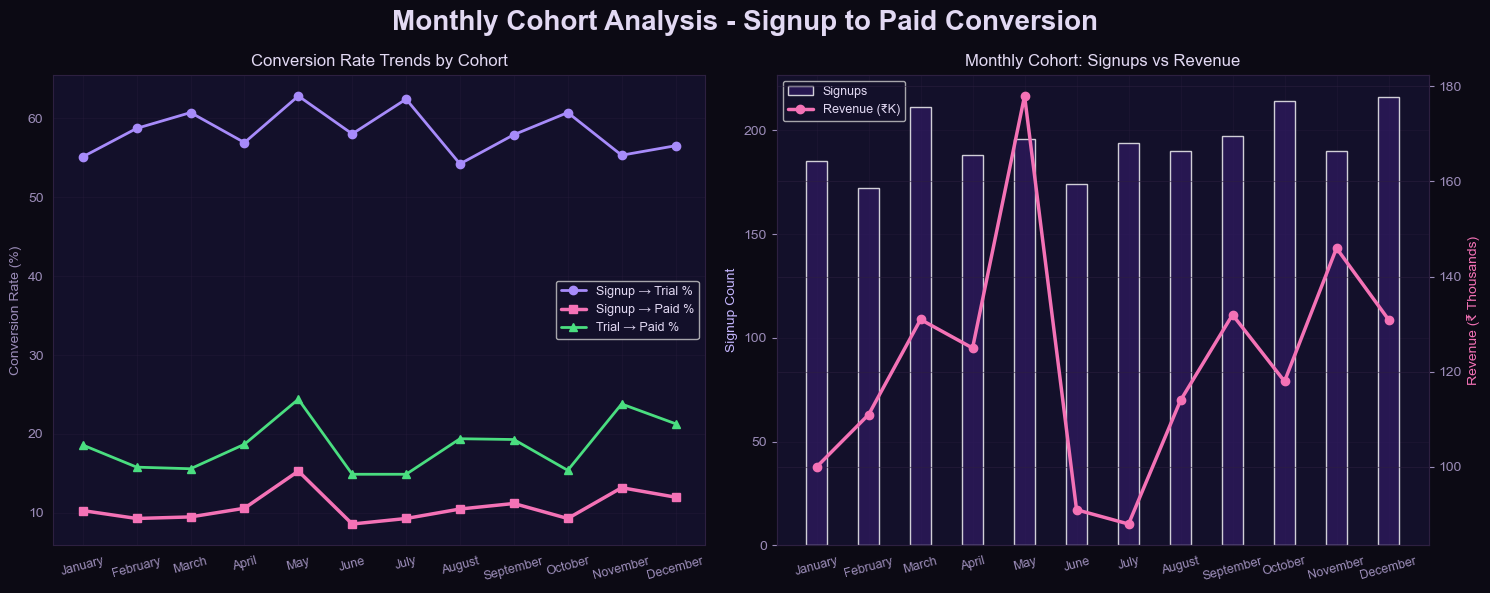

In [68]:
fig, axes = plt.subplots(1,2, figsize=(15, 6))
fig.suptitle("Monthly Cohort Analysis - Signup to Paid Conversion",
             fontsize=20, fontweight="bold", color="#E2D9F3")

months = cohort_stats['cohort_month'].tolist()
x = range(len(months))

# Charts 1 - cohort conversion rate trend
axes[0].plot(x, cohort_stats['trial_rate'], color="#A78BFA",
             linewidth=2, marker='o', markersize=6, label="Signup → Trial %")
axes[0].plot(x, cohort_stats["paid_rate"], color="#F472B6",
             linewidth=2.5, marker="s", markersize=6, label="Signup → Paid %")
axes[0].plot(x, cohort_stats["trial_to_paid"], color="#4ADE80",
             linewidth=2, marker="^", markersize=6, label="Trial → Paid %")
axes[0].set_xticks(x)
axes[0].set_xticklabels(months, rotation=15, fontsize=9)
axes[0].set_ylabel("Conversion Rate (%)")
axes[0].set_title("Conversion Rate Trends by Cohort", color="#E2D9F3")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Chart 2 — cohort revenue and volume
ax2b = axes[1].twinx()
axes[1].bar(x, cohort_stats["signups"], color="#2D1A5C",
            alpha=0.8, label="Signups", width=0.4)
ax2b.plot(x, cohort_stats["revenue"] / 1000, color="#F472B6",
          linewidth=2.5, marker="o", markersize=6, label="Revenue (₹K)")

axes[1].set_xticks(x)
axes[1].set_xticklabels(months, rotation=15, fontsize=9)
axes[1].set_ylabel("Signup Count", color="#C4B5FD")
ax2b.set_ylabel("Revenue (₹ Thousands)", color="#F472B6")
axes[1].set_title("Monthly Cohort: Signups vs Revenue", color="#E2D9F3")

lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
axes[1].legend(lines1+lines2, labels1+labels2, fontsize=9, loc="upper left")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUTS}/charts/04_cohort_analysis.png",
            dpi=150, bbox_inches="tight", facecolor="#0C0A14")
plt.show()

### Time-to-convert analysis

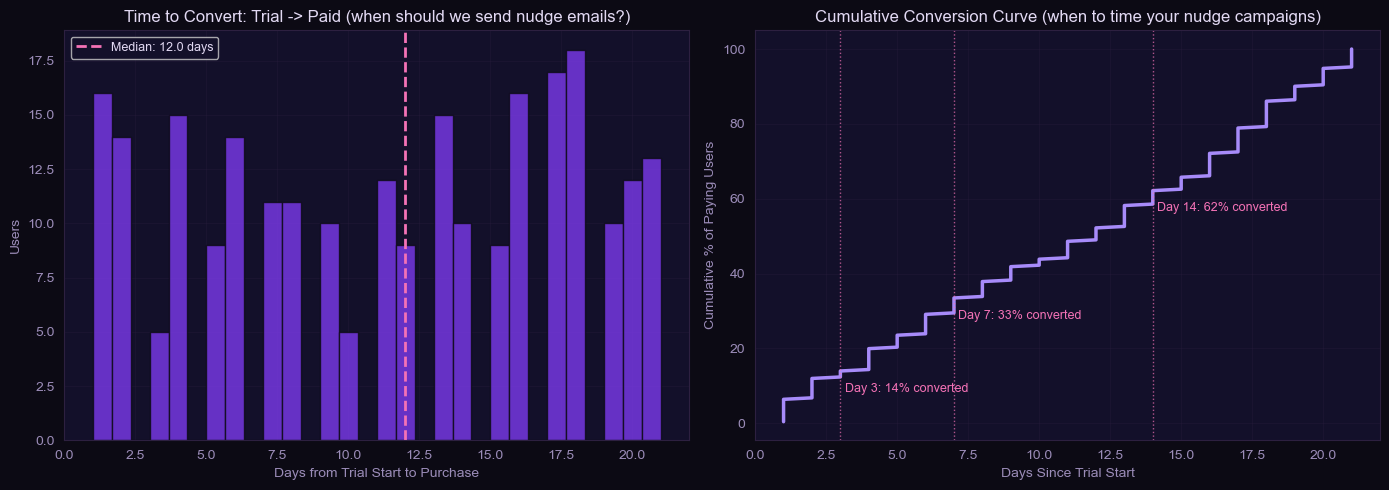

Median days trial → paid: 12.0
% converting within 7 days: 33.5%
% converting within 14 days: 62.2%


In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Days from trial start to paid conversion
paid_users = df[df['converted_paid']].copy()

axes[0].hist(paid_users['days_to_paid'].dropna(), bins=30,
             color='#7C3AED', alpha=0.8, edgecolor="#0C0A14")
axes[0].axvline(paid_users['days_to_paid'].median(), color='#F472B6',
                linewidth=2, linestyle="dashed",
                label=f"Median: {paid_users['days_to_paid'].median():.1f} days")
axes[0].set_xlabel("Days from Trial Start to Purchase")
axes[0].set_ylabel("Users")
axes[0].set_title("Time to Convert: Trial -> Paid (when should we send nudge emails?)", color="#E2D9F3")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Cumulative conversion - what % convert by day N?
sorted_days = paid_users['days_to_paid'].dropna().sort_values()
cumulative_pct = [i/len(sorted_days)*100 for i in range(1, len(sorted_days)+1)]

axes[1].plot(sorted_days, cumulative_pct, color="#A78BFA", linewidth=2.5)
for day_target in [3, 7, 14]:
    pct_by_day = (sorted_days <= day_target).sum() / len(sorted_days) * 100
    axes[1].axvline(day_target, color="#F472B6", linewidth=1, linestyle=":",
                    alpha=0.7)
    axes[1].annotate(f"Day {day_target}: {pct_by_day:.0f}% converted",
                     (day_target, pct_by_day),
                     xytext=(3, -15), textcoords="offset points",
                     fontsize=9, color="#F472B6")

axes[1].set_xlabel("Days Since Trial Start")
axes[1].set_ylabel("Cumulative % of Paying Users")
axes[1].set_title("Cumulative Conversion Curve (when to time your nudge campaigns)", color="#E2D9F3")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUTS}/charts/05_time_to_convert.png",
            dpi=150, bbox_inches="tight", facecolor="#0C0A14")
plt.show()

print(f"Median days trial → paid: {paid_users['days_to_paid'].median():.1f}")
print(f"% converting within 7 days: {(paid_users['days_to_paid']<=7).mean()*100:.1f}%")
print(f"% converting within 14 days: {(paid_users['days_to_paid']<=14).mean()*100:.1f}%")